# Predicción de Churn Bancario
**Métodos de Analítica II — Maestría en Analítica para la Inteligencia de Negocios**  
Pontificia Universidad Javeriana · Facultad de Ingeniería · Mayo 2026

---


## 0. Librerías

In [3]:
pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, classification_report
)
import xgboost as xgb

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#2563EB', '#DC2626']

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print("SHAP no instalado (pip install shap). Feature importance nativa disponible de todas formas.")

try:
    import torch, torch.nn as nn, torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_OK = True
    print(f"PyTorch {torch.__version__} disponible")
except ImportError:
    TORCH_OK = False
    print("PyTorch no disponible — se usará sklearn MLP.")

print("Librerías cargadas.")


PyTorch 2.12.0+cpu disponible
Librerías cargadas.


## 1. Carga y limpieza de datos

In [2]:
df = pd.read_excel(r"C:\Users\samu8\Downloads\bank_churn.xlsx")

# La variable objetivo viene como string ('Attrited Customer' / 'Existing Customer')
# la convertimos a binario antes de hacer cualquier otra cosa
df['attrition_flag'] = (
    df['attrition_flag']
    .str.lower()
    .str.contains('attrited|yes|1|true')
    .astype(int)
)

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['attrition_flag'].mean():.1%}")
print(f"Nulos: {df.isnull().sum().sum()}")
df.head()


Shape: (10127, 21)
Churn rate: 16.1%
Nulos: 0


,clientnum,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,...,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,768805383,0,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [4]:
print("Tipos de datos:")
print(df.dtypes)
print()
print("Estadísticos básicos:")
df.describe().T.round(2)


Tipos de datos:
clientnum                     int64
attrition_flag                int64
customer_age                  int64
gender                          str
dependent_count               int64
education_level                 str
marital_status                  str
income_category                 str
card_category                   str
months_on_book                int64
total_relationship_count      int64
months_inactive_12_mon        int64
contacts_count_12_mon         int64
credit_limit                float64
total_revolving_bal           int64
avg_open_to_buy             float64
total_amt_chng_q4_q1        float64
total_trans_amt               int64
total_trans_ct                int64
total_ct_chng_q4_q1         float64
avg_utilization_ratio       float64
dtype: object

Estadísticos básicos:


,count,mean,std,min,25%,50%,75%,max
clientnum,10127.0,7.391776e+08,36903783.45,708082083.0,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
attrition_flag,10127.0,1.600000e-01,0.37,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
customer_age,10127.0,4.633000e+01,8.02,26.0,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
dependent_count,10127.0,2.350000e+00,1.30,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
months_on_book,10127.0,3.593000e+01,7.99,13.0,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
total_relationship_count,10127.0,3.810000e+00,1.55,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
months_inactive_12_mon,10127.0,2.340000e+00,1.01,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
contacts_count_12_mon,10127.0,2.460000e+00,1.11,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
credit_limit,10127.0,8.631950e+03,9088.78,1438.3,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
total_revolving_bal,10127.0,1.162810e+03,814.99,0.0,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03


## 2. Análisis Exploratorio de Datos (EDA)

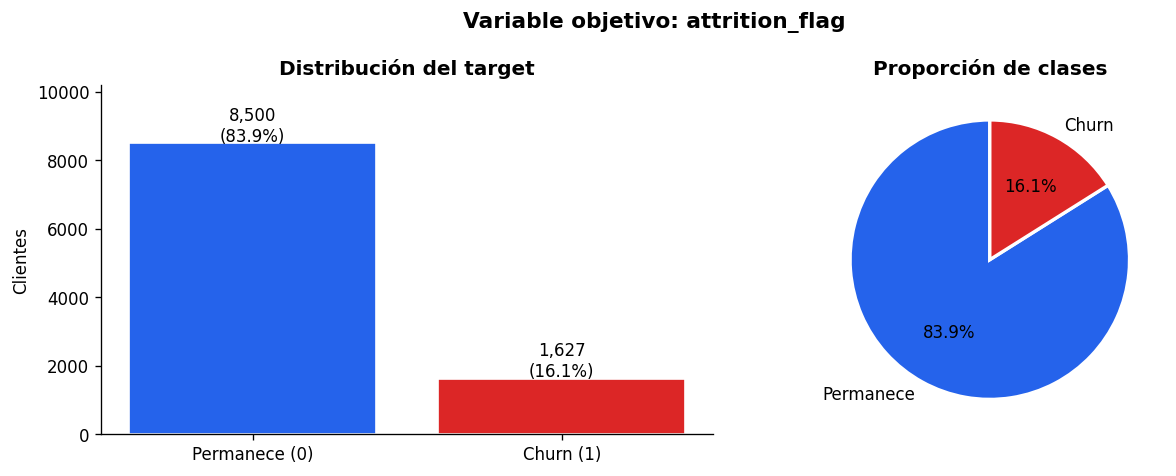

Ratio de desbalance: 5.2:1
Dataset desbalanceado — se usará stratify en el split y se priorizará Recall sobre Accuracy.


In [5]:
# ── Distribución del target ──────────────────────────────────────────────────
counts = df['attrition_flag'].value_counts()
pcts   = df['attrition_flag'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Permanece (0)', 'Churn (1)'], counts.values,
            color=PALETTE, edgecolor='white')
for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, v + 60, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Distribución del target', fontweight='bold')
axes[0].set_ylim(0, counts.max() * 1.2)
axes[0].set_ylabel('Clientes')

axes[1].pie(counts.values, labels=['Permanece', 'Churn'],
            colors=PALETTE, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporción de clases', fontweight='bold')

plt.suptitle('Variable objetivo: attrition_flag', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_01_target.png', bbox_inches='tight')
plt.show()

print(f"Ratio de desbalance: {counts[0]/counts[1]:.1f}:1")
print("Dataset desbalanceado — se usará stratify en el split y se priorizará Recall sobre Accuracy.")


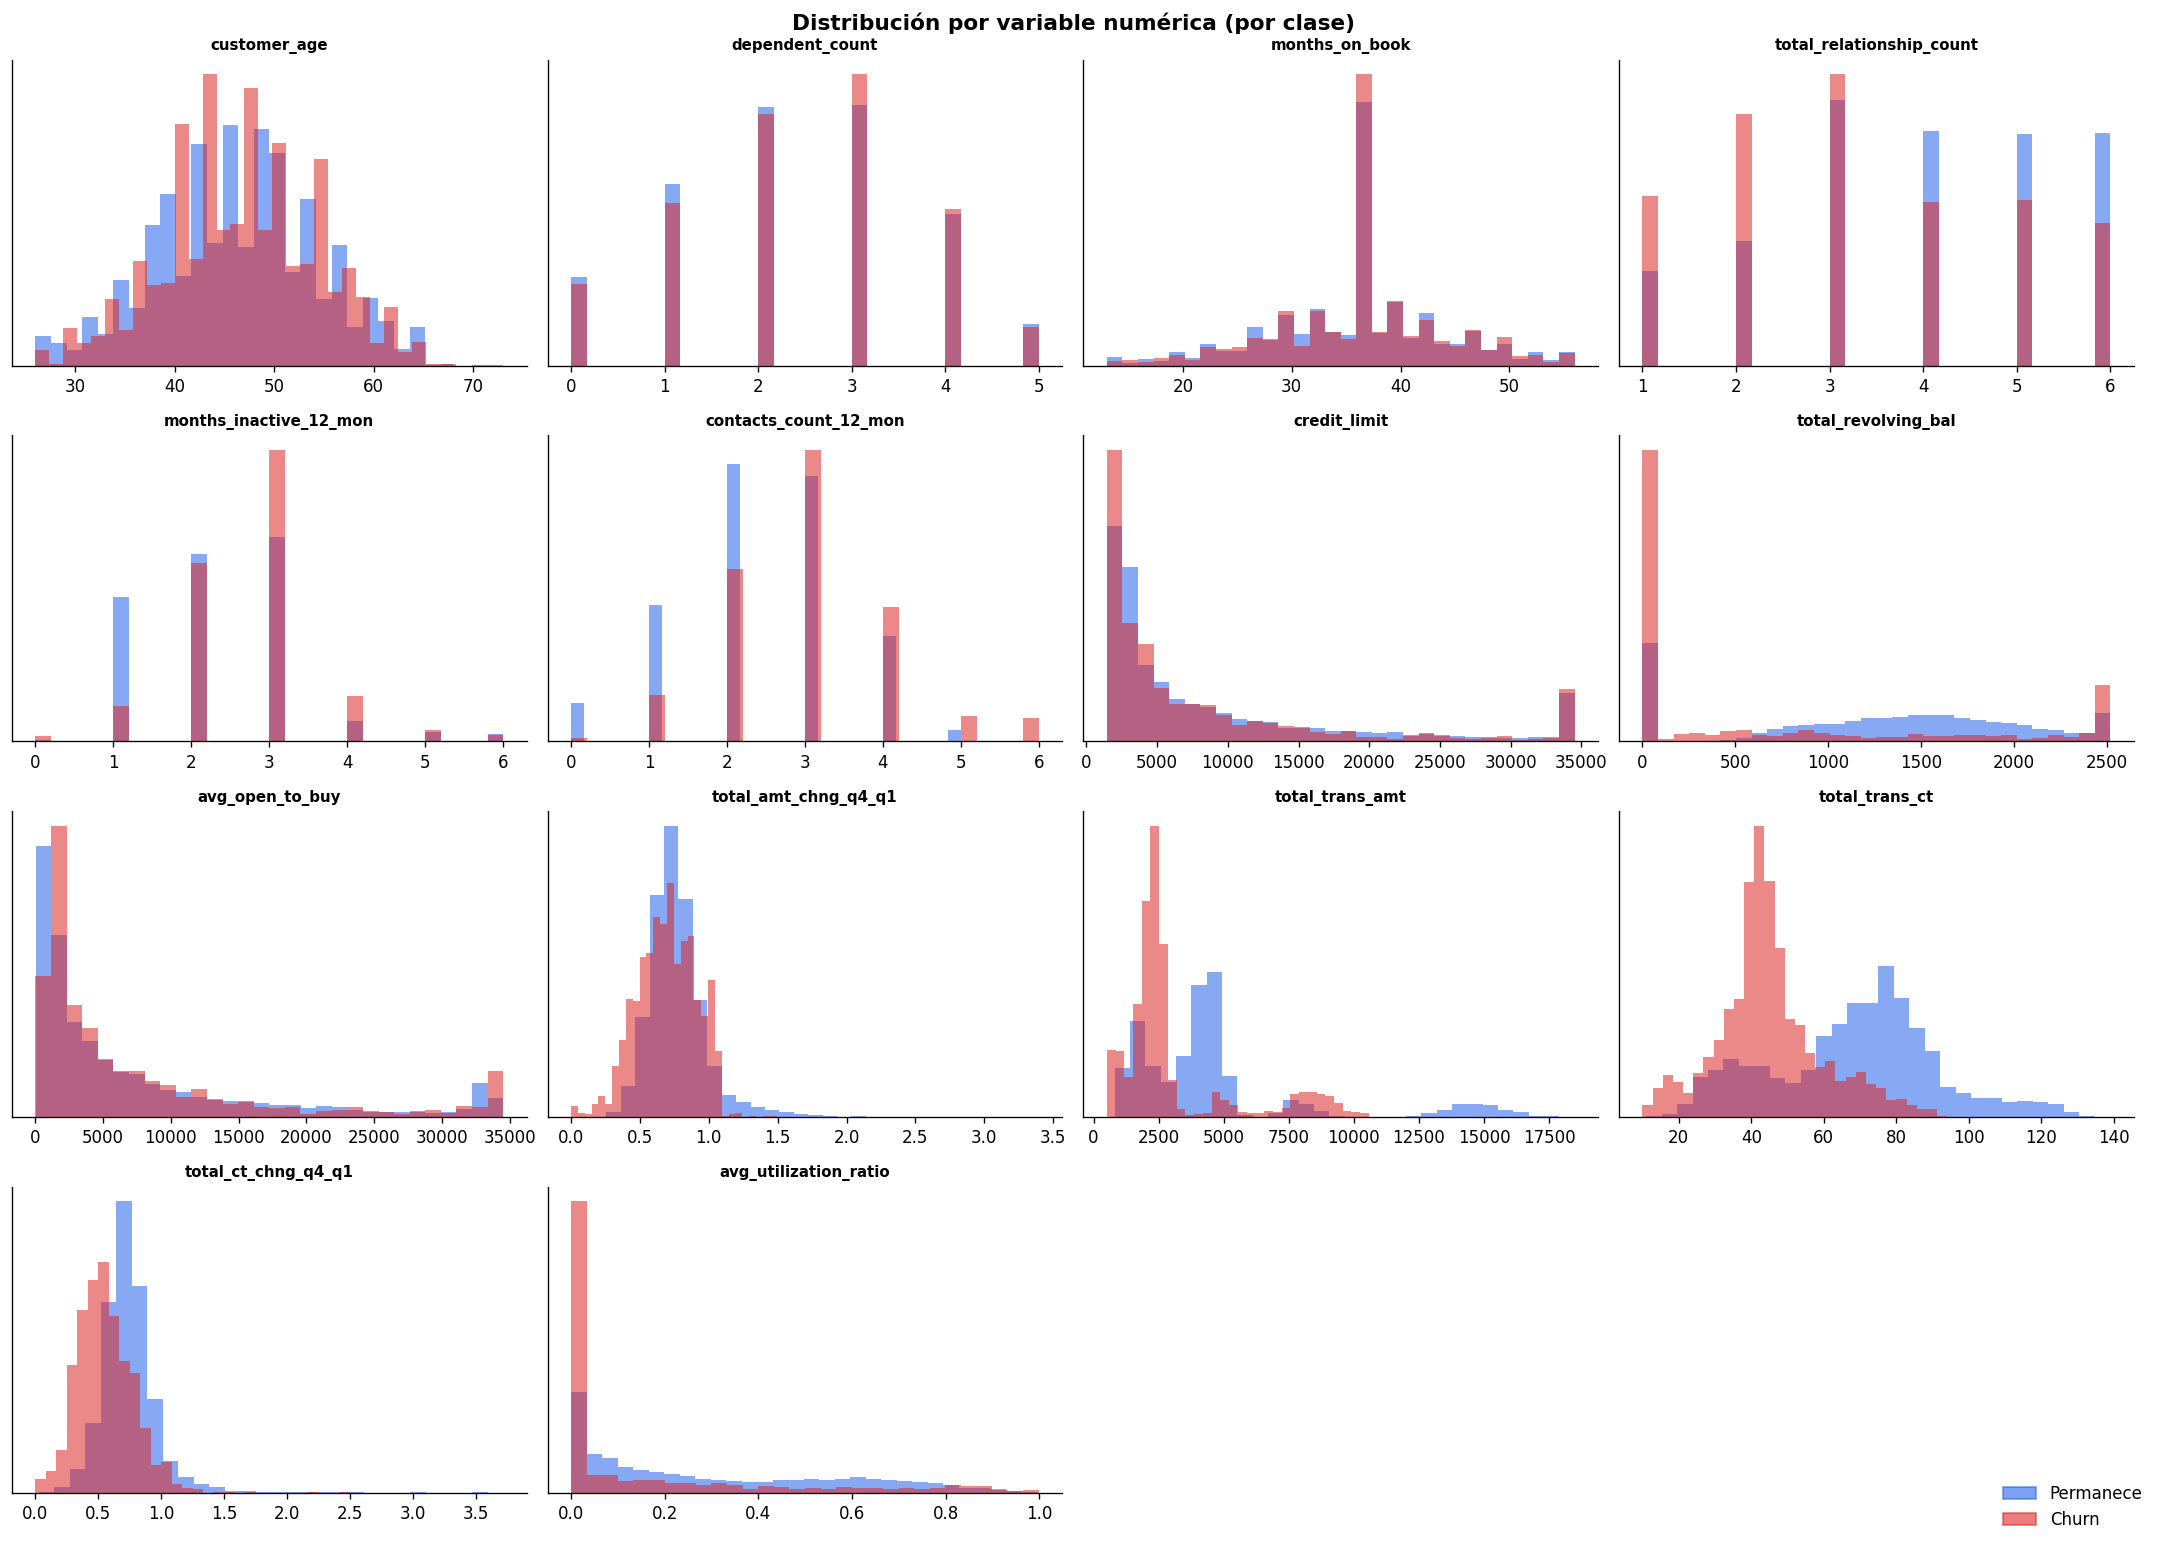

In [6]:
# ── Variables numéricas: ¿se ven distintas entre churners y no churners? ─────
num_vars = [
    'customer_age', 'dependent_count', 'months_on_book',
    'total_relationship_count', 'months_inactive_12_mon',
    'contacts_count_12_mon', 'credit_limit', 'total_revolving_bal',
    'avg_open_to_buy', 'total_amt_chng_q4_q1', 'total_trans_amt',
    'total_trans_ct', 'total_ct_chng_q4_q1', 'avg_utilization_ratio'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 13))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    for cls, color, label in zip([0, 1], PALETTE, ['Permanece', 'Churn']):
        axes[i].hist(df[df['attrition_flag'] == cls][var].dropna(),
                     bins=30, alpha=0.55, color=color, label=label,
                     edgecolor='none', density=True)
    axes[i].set_title(var, fontsize=9, fontweight='bold')
    axes[i].set_yticks([])

for j in range(len(num_vars), len(axes)):
    axes[j].set_visible(False)

handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.6) for c in PALETTE]
fig.legend(handles, ['Permanece', 'Churn'], loc='lower right', fontsize=10, frameon=False)
plt.suptitle('Distribución por variable numérica (por clase)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_02_numericas.png', bbox_inches='tight')
plt.show()


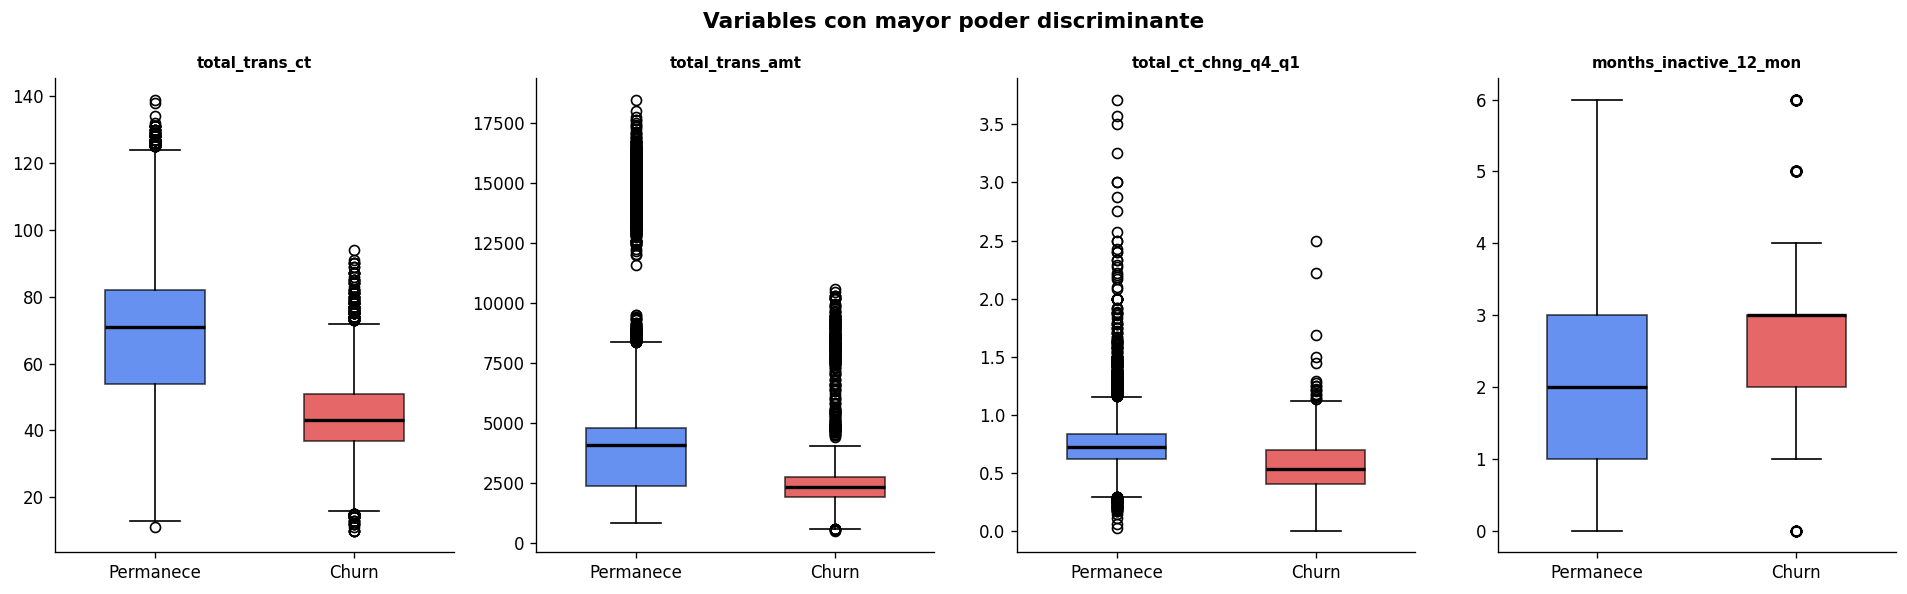

In [7]:
# ── Boxplots de las variables con mayor separación visual ────────────────────
key_vars = ['total_trans_ct', 'total_trans_amt', 'total_ct_chng_q4_q1', 'months_inactive_12_mon']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, var in zip(axes, key_vars):
    data = [df[df['attrition_flag'] == c][var] for c in [0, 1]]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(['Permanece', 'Churn'])
    ax.set_title(var, fontsize=9, fontweight='bold')

plt.suptitle('Variables con mayor poder discriminante', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_boxplots.png', bbox_inches='tight')
plt.show()


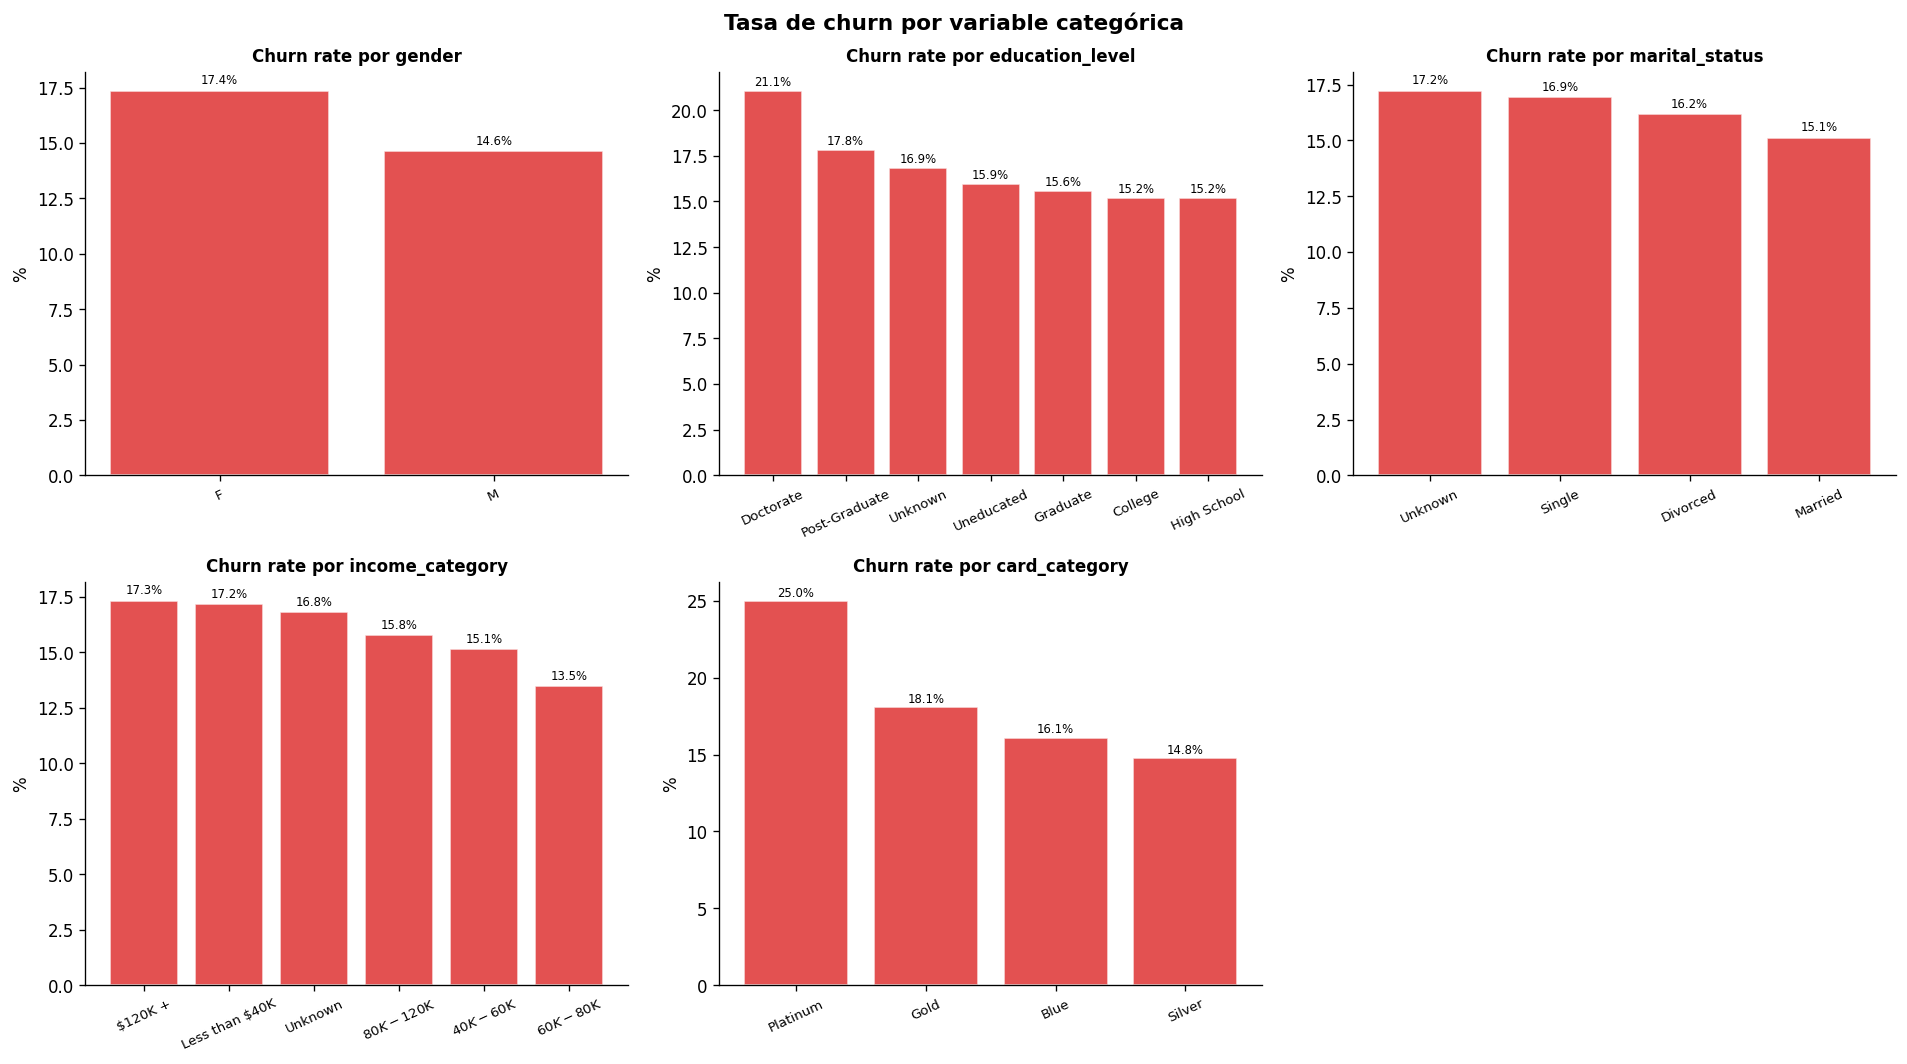

In [8]:
# ── Tasa de churn por variable categórica ────────────────────────────────────
cat_vars = ['gender', 'education_level', 'marital_status', 'income_category', 'card_category']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    ct = df.groupby(var)['attrition_flag'].mean() * 100
    ct = ct.sort_values(ascending=False)
    axes[i].bar(ct.index, ct.values, color=PALETTE[1], alpha=0.8, edgecolor='white')
    axes[i].set_title(f'Churn rate por {var}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('%')
    axes[i].tick_params(axis='x', rotation=25, labelsize=8)
    for j, v in enumerate(ct.values):
        axes[i].text(j, v + 0.3, f'{v:.1f}%', ha='center', fontsize=7)

axes[5].set_visible(False)
plt.suptitle('Tasa de churn por variable categórica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_categoricas.png', bbox_inches='tight')
plt.show()


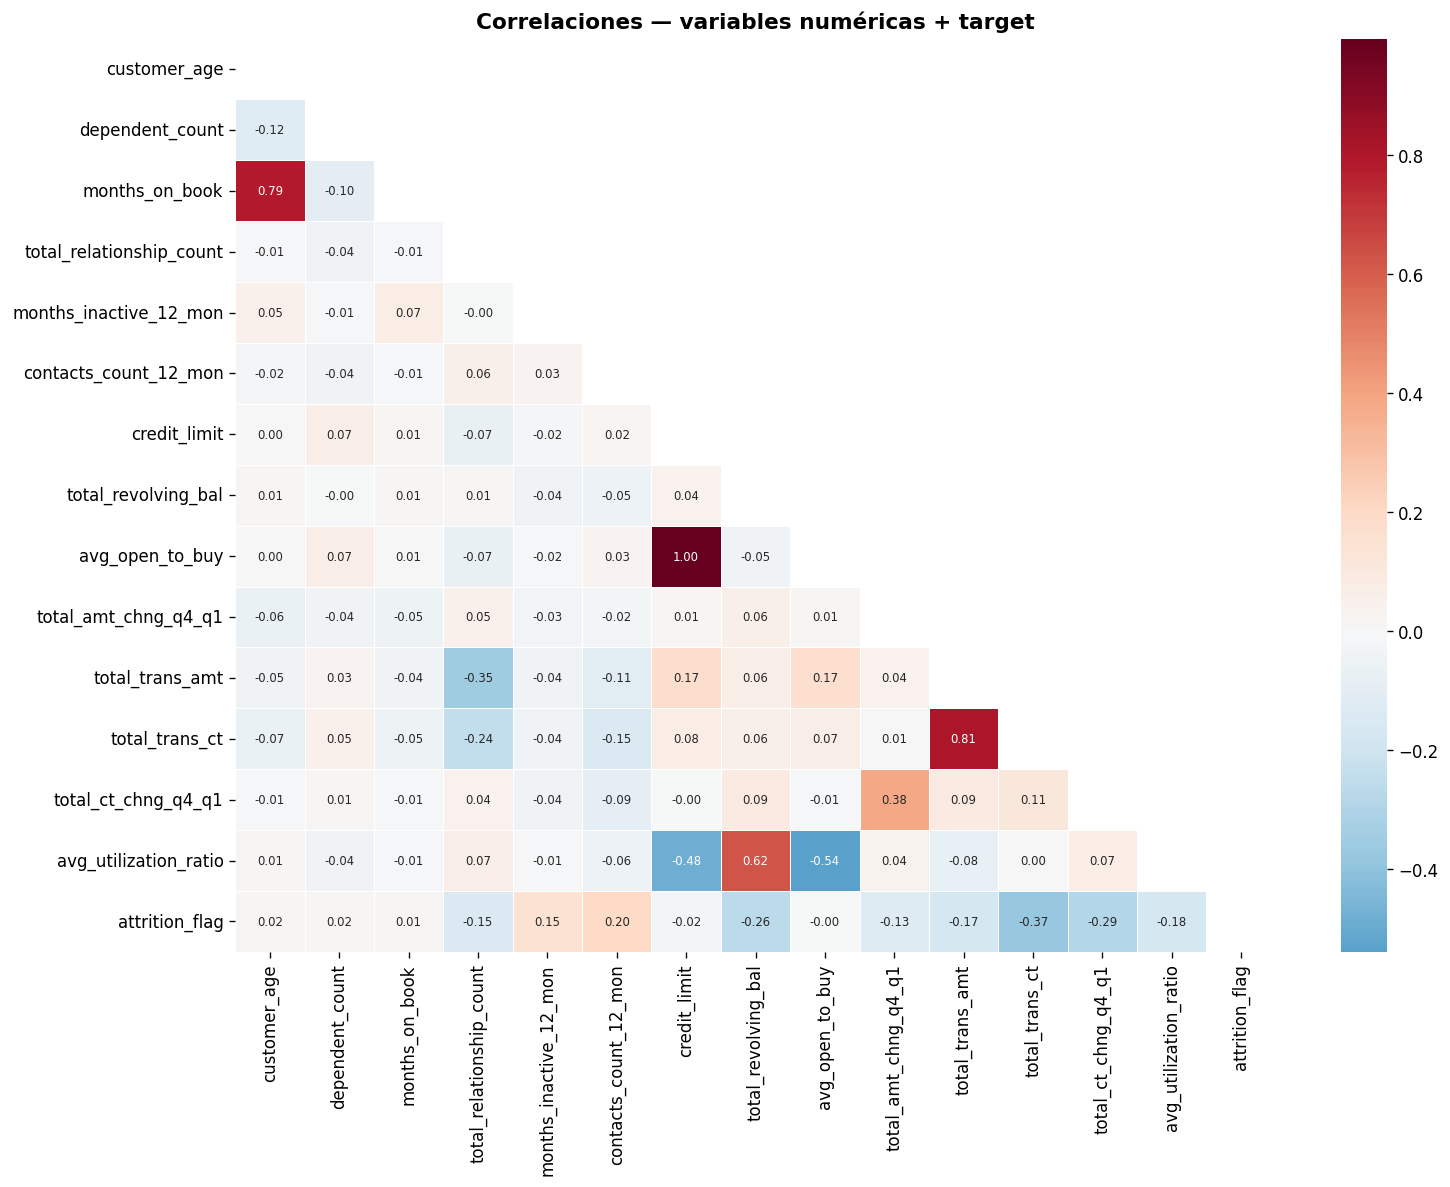

Top 8 correlaciones con el target:
total_trans_ct              0.371
total_ct_chng_q4_q1         0.290
total_revolving_bal         0.263
contacts_count_12_mon       0.204
avg_utilization_ratio       0.178
total_trans_amt             0.169
months_inactive_12_mon      0.152
total_relationship_count    0.150


In [9]:
# ── Mapa de correlaciones ────────────────────────────────────────────────────
corr = df[num_vars + ['attrition_flag']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlaciones — variables numéricas + target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_05_correlaciones.png', bbox_inches='tight')
plt.show()

print("Top 8 correlaciones con el target:")
print(corr['attrition_flag'].drop('attrition_flag').abs()
        .sort_values(ascending=False).head(8).round(3).to_string())


## 3. Preprocesamiento

In [10]:
cat_cols = ['gender', 'education_level', 'marital_status', 'income_category', 'card_category']
num_cols = [c for c in df.columns if c not in cat_cols + ['attrition_flag']]

X = df.drop(columns=['attrition_flag'])
y = df['attrition_flag']

# Split estratificado — preserva el 16% de churn en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# El preprocessor se ajusta SOLO sobre train para evitar data leakage
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

feature_names = (
    preprocessor.named_transformers_['cat']
                 .get_feature_names_out(cat_cols).tolist()
    + num_cols
)

print(f"Train: {X_train_prep.shape}  |  Test: {X_test_prep.shape}")
print(f"Churn en train: {y_train.mean():.1%}  |  Churn en test: {y_test.mean():.1%}")
print(f"Features tras encoding: {X_train_prep.shape[1]}")


Train: (8101, 33)  |  Test: (2026, 33)
Churn en train: 16.1%  |  Churn en test: 16.0%
Features tras encoding: 33


## 4. Entrenamiento y comparación de modelos

Se evalúan 6 modelos que cubren los temas del curso:

| Modelo | Tema |
|--------|------|
| Regresión Logística | Método del gradiente — línea base |
| SVM (kernel RBF) | SVM no linealmente separable |
| Random Forest | Ensambles — Bagging |
| AdaBoost | Ensambles — Boosting (ADABOOST) |
| XGBoost | Ensambles — XGBOOST / Gradient Boosting |
| Red Neuronal (MLP) | Redes neuronales feed-forward + backpropagation |

**Métrica principal: Recall** — en churn, no detectar a un cliente que se va (FN) cuesta más que ofrecer beneficios a alguien que no los necesitaba (FP).


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),

    'SVM (RBF)': SVC(kernel='rbf', C=1.0, gamma='scale',
                     probability=True, random_state=42),

    'Random Forest': RandomForestClassifier(n_estimators=200, min_samples_split=5,
                                            random_state=42, n_jobs=-1),

    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2),
        n_estimators=200, learning_rate=0.5, random_state=42),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=1.0, reg_lambda=5.0,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1),

    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(64, 32, 16),   # Input → 64 → 32 → 16 → 1
        activation='relu',                  # ReLU evita vanishing gradient en capas ocultas
        solver='adam',
        alpha=0.01,                         # L2 regularización
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        max_iter=300, random_state=42)
}


In [12]:
# Entrena todos los modelos y guarda resultados + modelos entrenados
results      = {}
trained      = {}
predictions  = {}

for name, model in models.items():
    print(f"Entrenando: {name}...", end='  ')
    model.fit(X_train_prep, y_train)
    trained[name] = model

    y_pred  = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1]

    predictions[name] = {'pred': y_pred, 'proba': y_proba}

    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
    }
    print(f"ROC-AUC: {results[name]['ROC-AUC']:.4f}  |  Recall: {results[name]['Recall']:.4f}")

results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print("\n── Tabla comparativa ──────────────────────────────────────────────")
print(results_df.round(4).to_string())


Entrenando: Logistic Regression...  ROC-AUC: 0.9177  |  Recall: 0.5538
Entrenando: SVM (RBF)...  ROC-AUC: 0.9597  |  Recall: 0.6800
Entrenando: Random Forest...  ROC-AUC: 0.9838  |  Recall: 0.7600
Entrenando: AdaBoost...  ROC-AUC: 0.9887  |  Recall: 0.8308
Entrenando: XGBoost...  ROC-AUC: 0.9919  |  Recall: 0.8585
Entrenando: Neural Network...  ROC-AUC: 0.9576  |  Recall: 0.7169

── Tabla comparativa ──────────────────────────────────────────────
                     Accuracy  Precision  Recall      F1  ROC-AUC
XGBoost                0.9704     0.9522  0.8585  0.9029   0.9919
AdaBoost               0.9650     0.9441  0.8308  0.8838   0.9887
Random Forest          0.9536     0.9392  0.7600  0.8401   0.9838
SVM (RBF)              0.9353     0.8911  0.6800  0.7714   0.9597
Neural Network         0.9319     0.8351  0.7169  0.7715   0.9576
Logistic Regression    0.9042     0.7860  0.5538  0.6498   0.9177


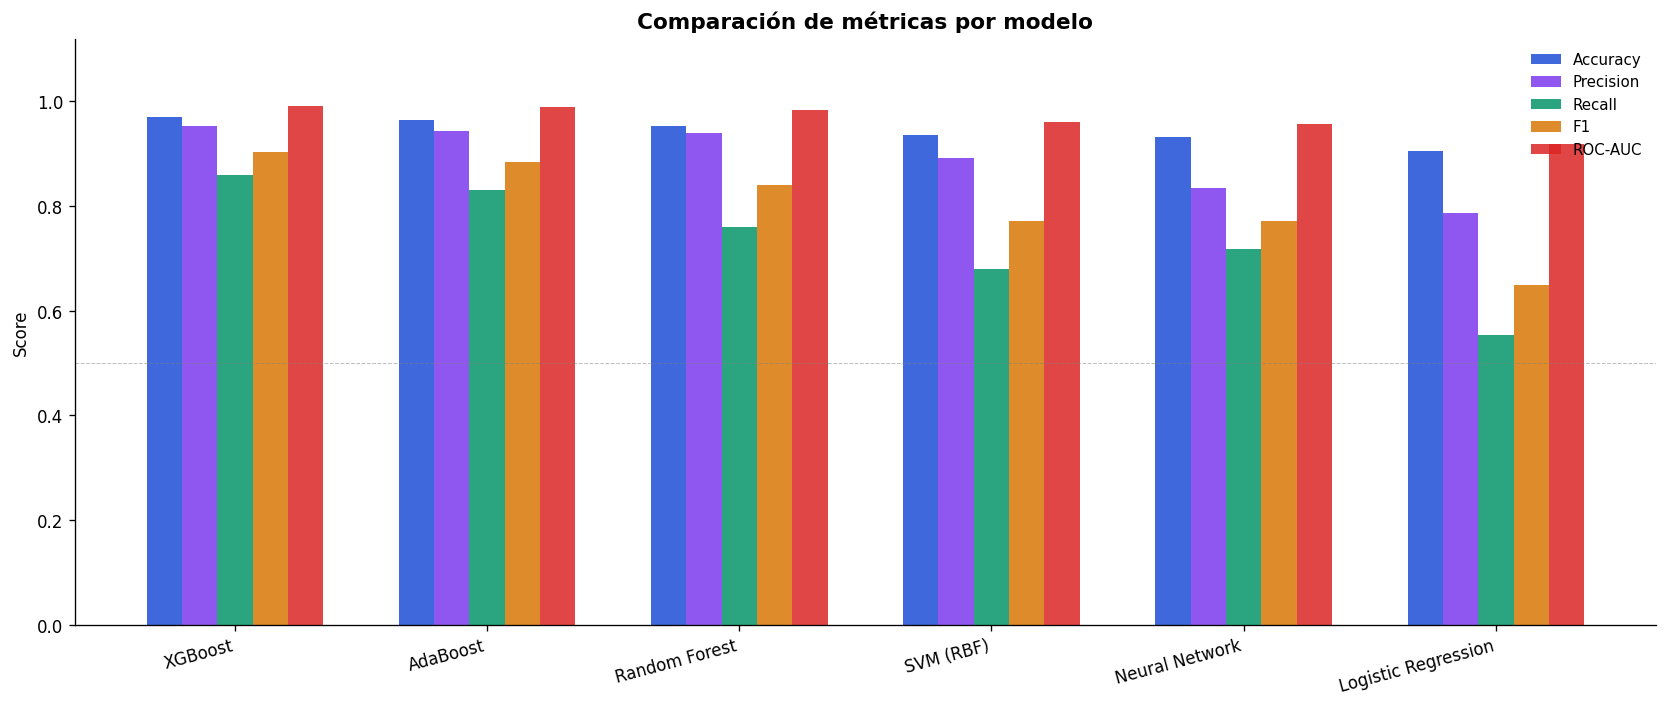

In [13]:
# ── Comparación visual de métricas ──────────────────────────────────────────
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
colors_m = ['#1d4ed8', '#7c3aed', '#059669', '#d97706', '#dc2626']
x        = np.arange(len(results_df))
width    = 0.14

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    bars = ax.bar(x + i * width, results_df[metric], width,
                  label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Comparación de métricas por modelo', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, frameon=False)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
plt.tight_layout()
plt.savefig('fig_06_comparacion_modelos.png', bbox_inches='tight')
plt.show()


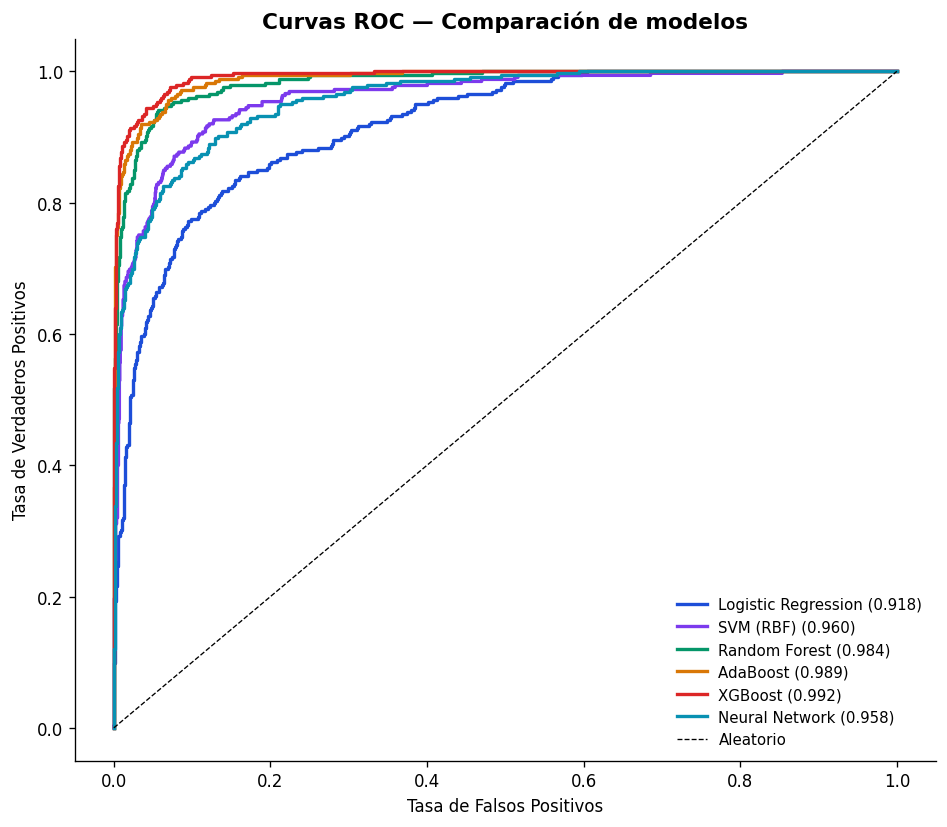

In [14]:
# ── Curvas ROC de todos los modelos ─────────────────────────────────────────
colors_roc = ['#1d4ed8', '#7c3aed', '#059669', '#d97706', '#dc2626', '#0891b2']

fig, ax = plt.subplots(figsize=(8, 7))
for (name, model), color in zip(trained.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, predictions[name]['proba'])
    auc = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, label=f'{name} ({auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC — Comparación de modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig('fig_07_roc_curves.png', bbox_inches='tight')
plt.show()


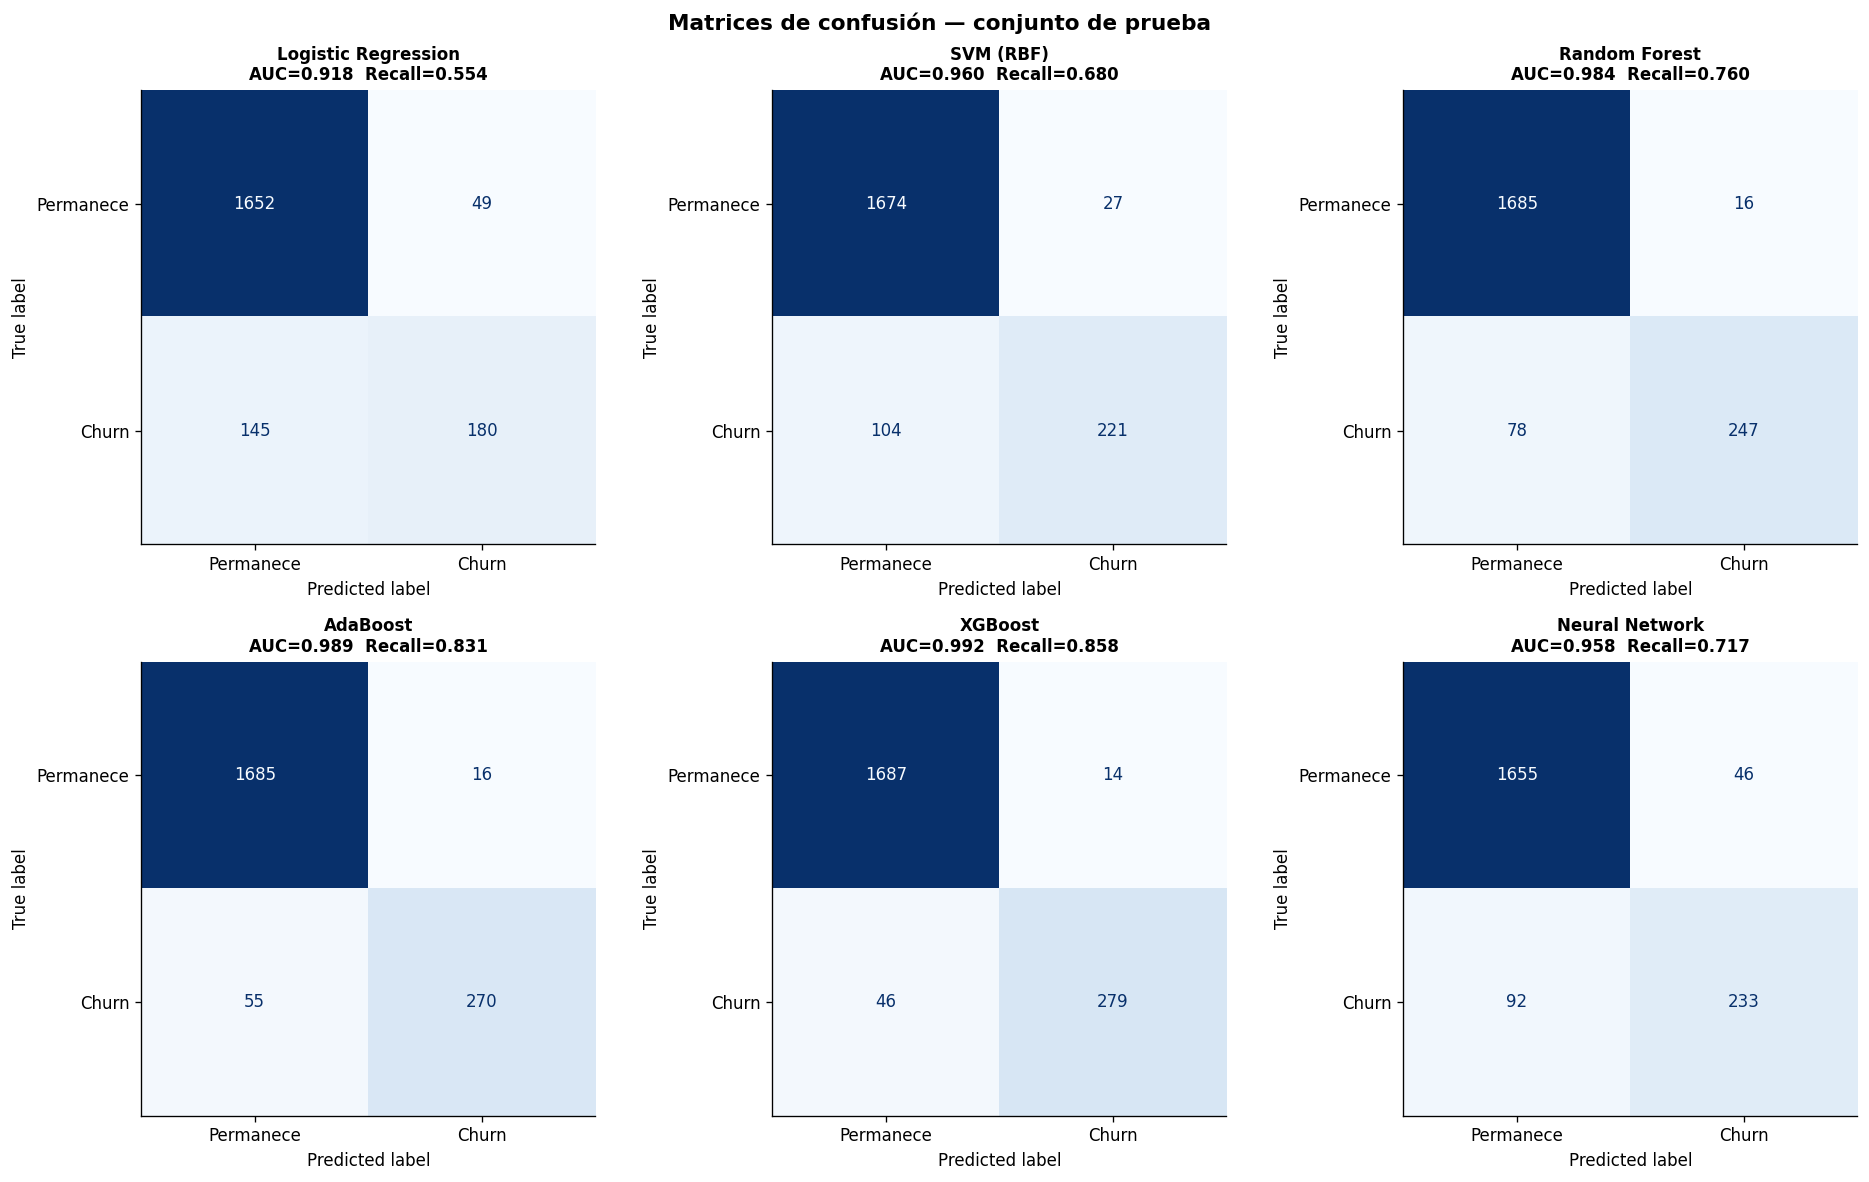

In [15]:
# ── Matrices de confusión: todos los modelos en una figura ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained.items()):
    cm = confusion_matrix(y_test, predictions[name]['pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Permanece', 'Churn']).plot(
        ax=axes[i], colorbar=False, cmap='Blues')
    auc = results[name]['ROC-AUC']
    rec = results[name]['Recall']
    axes[i].set_title(f'{name}\nAUC={auc:.3f}  Recall={rec:.3f}',
                      fontsize=10, fontweight='bold')

plt.suptitle('Matrices de confusión — conjunto de prueba', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_08_confusion_matrices.png', bbox_inches='tight')
plt.show()


## 5. Selección del modelo final

Se selecciona el modelo con mayor **ROC-AUC** en test y gap train-test mínimo (descarta overfitting).  
Se verifica adicionalmente con validación cruzada de 5 folds.


In [16]:
# Modelo con mayor ROC-AUC
best_name  = results_df['ROC-AUC'].idxmax()
best_model = trained[best_name]
y_pred_b   = predictions[best_name]['pred']
y_proba_b  = predictions[best_name]['proba']

print(f"Modelo seleccionado: {best_name}")
print(f"\nMétricas en test:")
for k, v in results[best_name].items():
    print(f"  {k:<12}: {v:.4f}")

# Gap train vs test
y_proba_train = best_model.predict_proba(X_train_prep)[:, 1]
train_auc = roc_auc_score(y_train, y_proba_train)
test_auc  = results[best_name]['ROC-AUC']
print(f"\nTrain AUC: {train_auc:.4f}  |  Test AUC: {test_auc:.4f}  |  Gap: {train_auc - test_auc:.4f}")


Modelo seleccionado: XGBoost

Métricas en test:
  Accuracy    : 0.9704
  Precision   : 0.9522
  Recall      : 0.8585
  F1          : 0.9029
  ROC-AUC     : 0.9919

Train AUC: 0.9997  |  Test AUC: 0.9919  |  Gap: 0.0078


In [17]:
# ── Validación cruzada 5-fold sobre el modelo seleccionado ──────────────────
X_full_prep = preprocessor.transform(X)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    best_model, X_full_prep, y, cv=cv,
    scoring={'accuracy': 'accuracy', 'recall': 'recall',
             'precision': 'precision', 'f1': 'f1', 'roc_auc': 'roc_auc'}
)

print(f"── Cross-Validation 5-Fold — {best_name} ──────────────────────────────")
for metric in ['accuracy', 'recall', 'precision', 'f1', 'roc_auc']:
    vals = cv_results[f'test_{metric}']
    print(f"  {metric.capitalize():<12}: {vals.mean():.4f} ± {vals.std():.4f}")


── Cross-Validation 5-Fold — XGBoost ──────────────────────────────
  Accuracy    : 0.9723 ± 0.0038
  Recall      : 0.8893 ± 0.0181
  Precision   : 0.9350 ± 0.0147
  F1          : 0.9115 ± 0.0125
  Roc_auc     : 0.9933 ± 0.0017


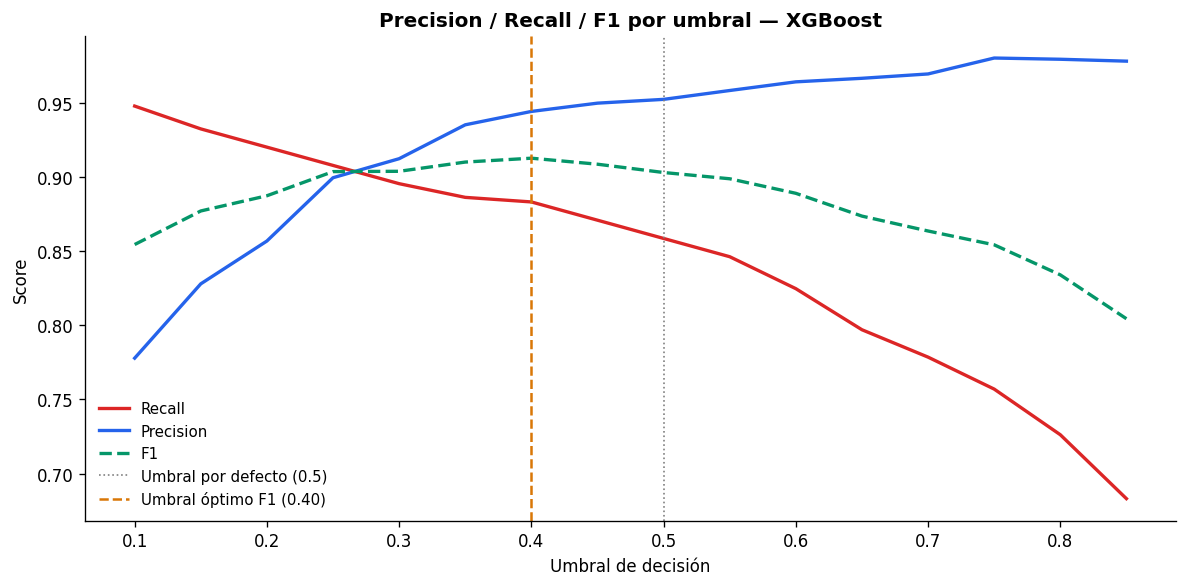

Umbral óptimo para F1: 0.40  →  F1 = 0.9126


In [18]:
# ── Análisis de umbral de decisión ──────────────────────────────────────────
# Por defecto el umbral es 0.5, pero podemos moverlo para capturar más churners
thresholds  = np.arange(0.1, 0.9, 0.05)
recalls, precisions, f1s = [], [], []

for thr in thresholds:
    y_thr = (y_proba_b >= thr).astype(int)
    recalls.append(recall_score(y_test, y_thr, zero_division=0))
    precisions.append(precision_score(y_test, y_thr, zero_division=0))
    f1s.append(f1_score(y_test, y_thr, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, recalls,    color='#dc2626', linewidth=2, label='Recall')
ax.plot(thresholds, precisions, color='#2563EB', linewidth=2, label='Precision')
ax.plot(thresholds, f1s,        color='#059669', linewidth=2, linestyle='--', label='F1')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1, label='Umbral por defecto (0.5)')

best_thr = thresholds[np.argmax(f1s)]
ax.axvline(best_thr, color='#d97706', linestyle='--', linewidth=1.5,
           label=f'Umbral óptimo F1 ({best_thr:.2f})')

ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Score')
ax.set_title(f'Precision / Recall / F1 por umbral — {best_name}',
             fontsize=12, fontweight='bold')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('fig_09_threshold.png', bbox_inches='tight')
plt.show()

print(f"Umbral óptimo para F1: {best_thr:.2f}  →  F1 = {max(f1s):.4f}")


## 6. Interpretabilidad del modelo seleccionado

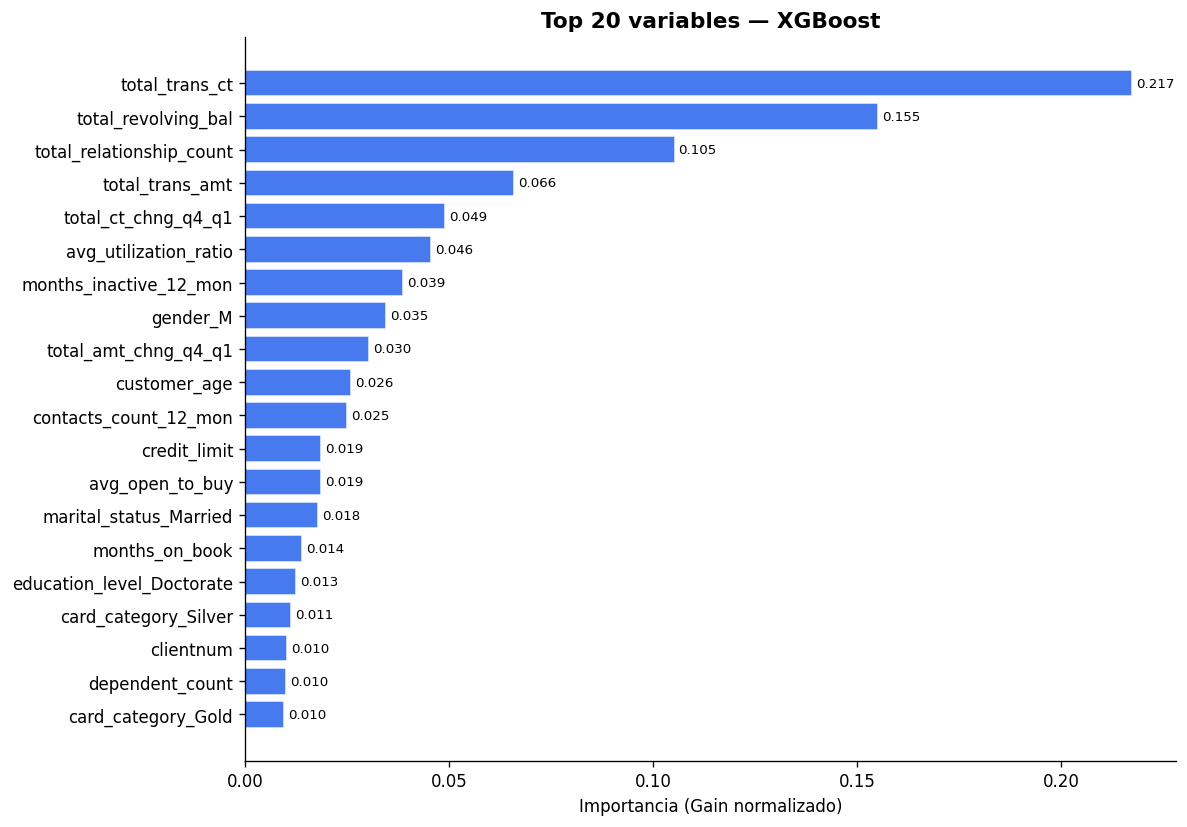

Top 10 variables más importantes:
                 Feature  Importance
          total_trans_ct    0.217330
     total_revolving_bal    0.155136
total_relationship_count    0.105310
         total_trans_amt    0.065909
     total_ct_chng_q4_q1    0.049033
   avg_utilization_ratio    0.045591
  months_inactive_12_mon    0.038720
                gender_M    0.034641
    total_amt_chng_q4_q1    0.030424
            customer_age    0.026063


In [19]:
# ── Feature importance ───────────────────────────────────────────────────────
# Funciona para XGBoost y Random Forest; si el mejor modelo cambia, ajustar
if hasattr(best_model, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'Feature':    feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    top20 = imp_df.head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top20['Feature'][::-1], top20['Importance'][::-1],
            color='#2563EB', alpha=0.85, edgecolor='white')
    ax.set_xlabel('Importancia (Gain normalizado)')
    ax.set_title(f'Top 20 variables — {best_name}', fontsize=13, fontweight='bold')
    for bar in ax.patches:
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('fig_10_feature_importance.png', bbox_inches='tight')
    plt.show()

    print("Top 10 variables más importantes:")
    print(top20.head(10).to_string(index=False))
else:
    print(f"{best_name} no tiene feature_importances_ nativo. Usar SHAP para interpretabilidad.")


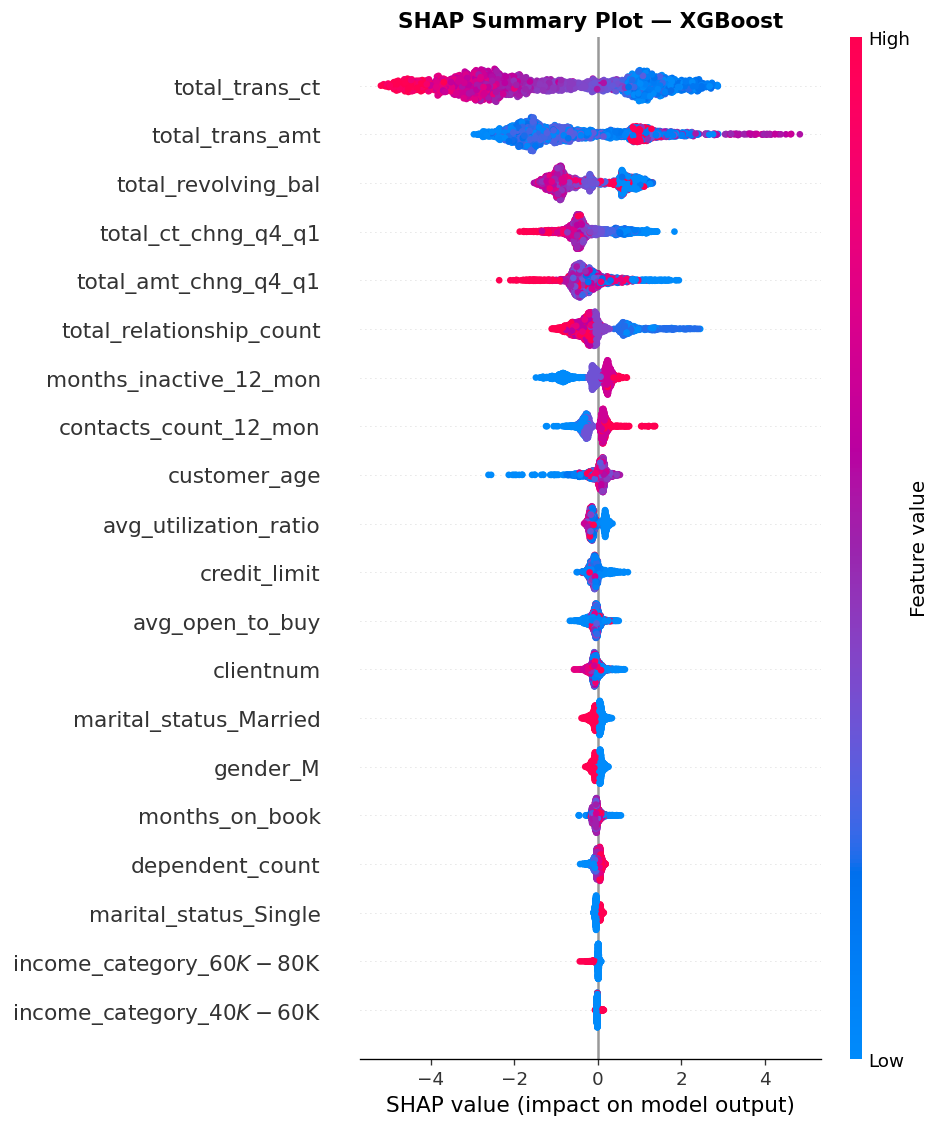

In [20]:
# ── SHAP (si está disponible) ────────────────────────────────────────────────
if SHAP_OK and hasattr(best_model, 'feature_importances_'):
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_prep)

    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(shap_values, X_test_prep,
                      feature_names=feature_names, show=False)
    plt.title(f'SHAP Summary Plot — {best_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_11_shap.png', bbox_inches='tight')
    plt.show()
elif not SHAP_OK:
    print("SHAP no disponible (pip install shap). Se usa feature importance nativa.")


## 7. Análisis de ensambles (Bagging vs. Boosting)

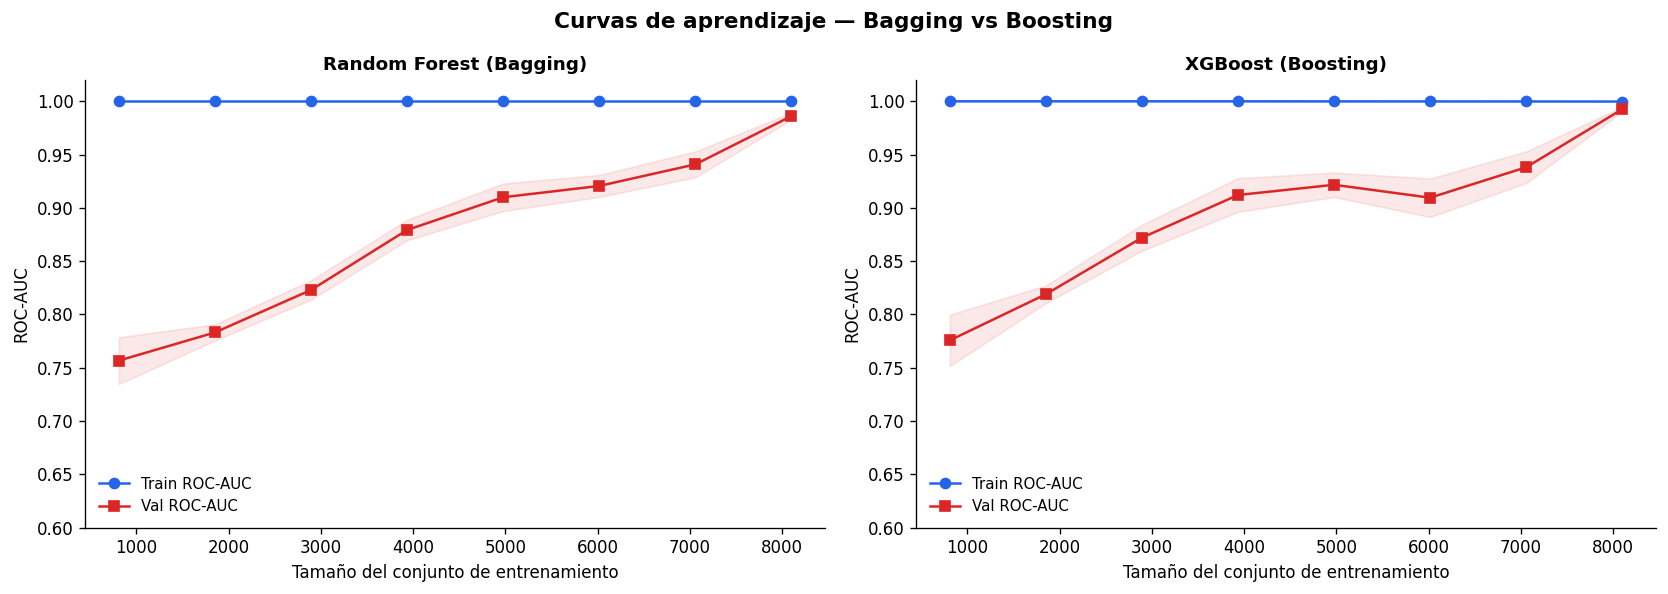

In [21]:
# ── Curvas de aprendizaje: Random Forest vs XGBoost ─────────────────────────
# Muestra cómo cada paradigma reduce el error a medida que hay más datos de entrenamiento
train_sizes = np.linspace(0.1, 1.0, 8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, clf) in zip(axes, [
        ('Random Forest (Bagging)',
         RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('XGBoost (Boosting)',
         xgb.XGBClassifier(n_estimators=100, learning_rate=0.1,
                            use_label_encoder=False, eval_metric='logloss',
                            random_state=42, n_jobs=-1))]):

    tr_sz, tr_sc, val_sc = learning_curve(
        clf, X_full_prep, y, train_sizes=train_sizes,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='roc_auc', n_jobs=-1)

    tr_m, tr_s   = tr_sc.mean(axis=1),  tr_sc.std(axis=1)
    val_m, val_s = val_sc.mean(axis=1), val_sc.std(axis=1)

    ax.plot(tr_sz, tr_m, 'o-', color='#2563EB', label='Train ROC-AUC')
    ax.plot(tr_sz, val_m, 's-', color='#dc2626', label='Val ROC-AUC')
    ax.fill_between(tr_sz, tr_m - tr_s, tr_m + tr_s, alpha=0.1, color='#2563EB')
    ax.fill_between(tr_sz, val_m - val_s, val_m + val_s, alpha=0.1, color='#dc2626')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('ROC-AUC')
    ax.legend(frameon=False, fontsize=9)
    ax.set_ylim(0.6, 1.02)

plt.suptitle('Curvas de aprendizaje — Bagging vs Boosting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_12_learning_curves.png', bbox_inches='tight')
plt.show()


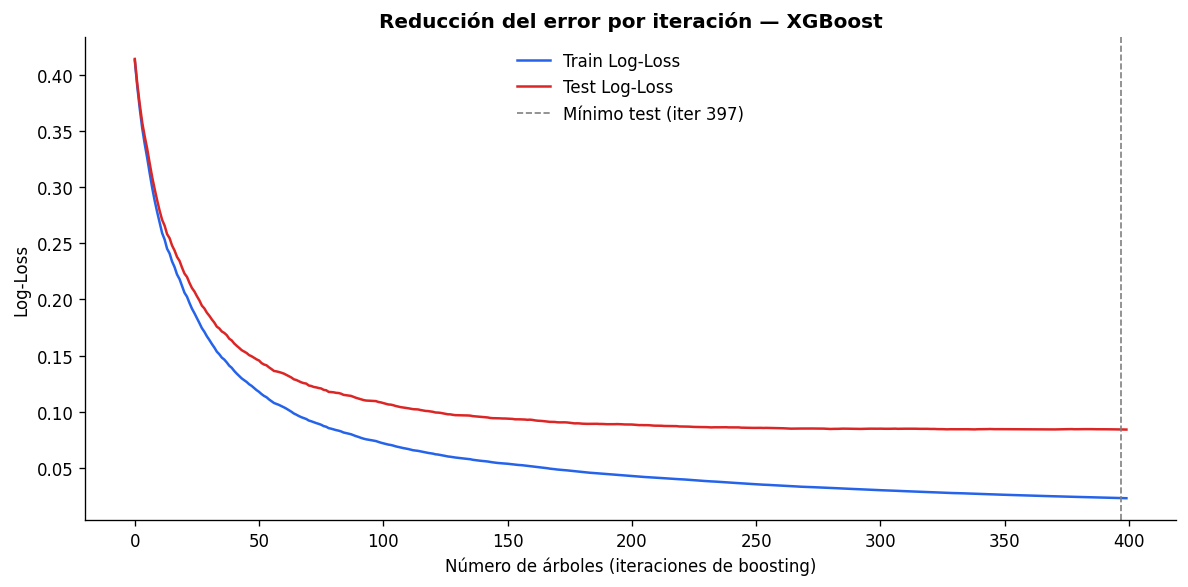

Mejor iteración: 397  |  Test Log-Loss mínimo: 0.0841


In [22]:
# ── Evolución del error de XGBoost iteración por iteración ──────────────────
# Cada árbol corrige los errores del anterior (así funciona el boosting)
xgb_eval = xgb.XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=5.0,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb_eval.fit(X_train_prep, y_train,
             eval_set=[(X_train_prep, y_train), (X_test_prep, y_test)],
             verbose=False)

evals      = xgb_eval.evals_result()
train_loss = evals['validation_0']['logloss']
test_loss  = evals['validation_1']['logloss']
best_iter  = int(np.argmin(test_loss))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_loss, color='#2563EB', linewidth=1.5, label='Train Log-Loss')
ax.plot(test_loss,  color='#dc2626', linewidth=1.5, label='Test Log-Loss')
ax.axvline(best_iter, color='gray', linestyle='--', linewidth=1,
           label=f'Mínimo test (iter {best_iter})')
ax.set_xlabel('Número de árboles (iteraciones de boosting)')
ax.set_ylabel('Log-Loss')
ax.set_title('Reducción del error por iteración — XGBoost', fontsize=12, fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('fig_13_xgb_iterations.png', bbox_inches='tight')
plt.show()

print(f"Mejor iteración: {best_iter}  |  Test Log-Loss mínimo: {test_loss[best_iter]:.4f}")


## 8. Red neuronal — detalle del proceso de aprendizaje

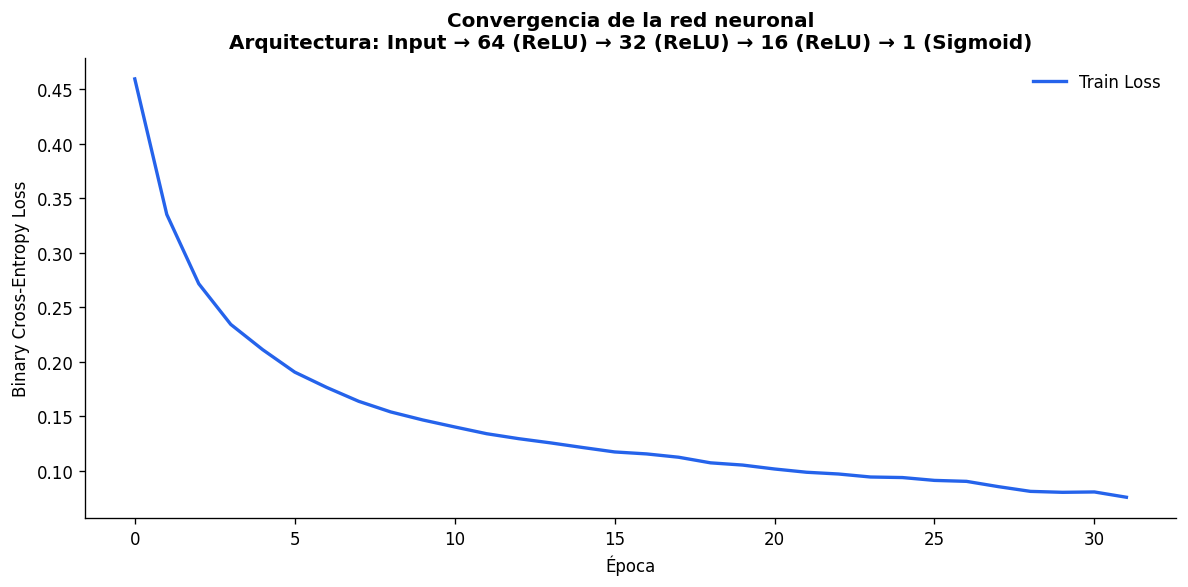

Épocas hasta convergencia: 32
Early stopping activado a partir de época: 17


In [23]:
# ── Curva de pérdida de la red neuronal (backpropagation época a época) ──────
nn_model = trained['Neural Network']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(nn_model.loss_curve_, color='#2563EB', linewidth=2, label='Train Loss')
if nn_model.best_loss_ is not None:
    ax.axhline(nn_model.best_loss_, color='#dc2626', linewidth=1.5,
               linestyle='--', label=f'Best val loss ({nn_model.best_loss_:.4f})')
ax.set_xlabel('Época')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.set_title('Convergencia de la red neuronal\n'
             'Arquitectura: Input → 64 (ReLU) → 32 (ReLU) → 16 (ReLU) → 1 (Sigmoid)',
             fontsize=12, fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('fig_14_nn_loss.png', bbox_inches='tight')
plt.show()

print(f"Épocas hasta convergencia: {nn_model.n_iter_}")
print(f"Early stopping activado a partir de época: {nn_model.n_iter_ - 15}")


In [24]:
# ── Implementación explícita en PyTorch (fases forward y backward) ───────────
if TORCH_OK:
    X_tr_t = torch.FloatTensor(X_train_prep)
    X_te_t = torch.FloatTensor(X_test_prep)
    y_tr_t = torch.FloatTensor(y_train.values).unsqueeze(1)
    y_te_t = torch.FloatTensor(y_test.values).unsqueeze(1)

    train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

    class ChurnNet(nn.Module):
        def __init__(self, n_in):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_in, 64), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(64, 32),   nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(32, 16),   nn.ReLU(),
                nn.Linear(16, 1),    nn.Sigmoid()
            )
        def forward(self, x):
            return self.net(x)

    torch_model = ChurnNet(X_tr_t.shape[1])
    criterion   = nn.BCELoss()
    optimizer   = optim.Adam(torch_model.parameters(), lr=0.001, weight_decay=1e-4)

    train_losses = []
    torch_model.train()
    for epoch in range(50):
        ep_loss = 0.0
        for X_b, y_b in train_dl:
            optimizer.zero_grad()
            loss = criterion(torch_model(X_b), y_b)  # forward
            loss.backward()                           # backward (gradientes)
            optimizer.step()                          # actualiza pesos
            ep_loss += loss.item()
        train_losses.append(ep_loss / len(train_dl))
        if (epoch + 1) % 10 == 0:
            print(f"Época {epoch+1}/50  |  Loss: {train_losses[-1]:.4f}")

    torch_model.eval()
    with torch.no_grad():
        proba_torch = torch_model(X_te_t).numpy().flatten()
        pred_torch  = (proba_torch >= 0.5).astype(int)

    print(f"\nPyTorch MLP — ROC-AUC: {roc_auc_score(y_te_t.numpy(), proba_torch):.4f}")
    print(f"PyTorch MLP — Recall:  {recall_score(y_te_t.numpy(), pred_torch):.4f}")
else:
    print("PyTorch no instalado. La red neuronal de sklearn (Sección 4) es funcionalmente equivalente.")


Época 10/50  |  Loss: 0.1716
Época 20/50  |  Loss: 0.1445
Época 30/50  |  Loss: 0.1293
Época 40/50  |  Loss: 0.1193
Época 50/50  |  Loss: 0.1118

PyTorch MLP — ROC-AUC: 0.9648
PyTorch MLP — Recall:  0.7538


## 9. Simulación Montecarlo — Impacto económico del programa de retención

In [25]:
# ── Parámetros del modelo de negocio ────────────────────────────────────────
# Todos los valores son inciertos, por eso usamos distribuciones en lugar de
# un valor puntual. Con 10.000 simulaciones obtenemos un intervalo de confianza.

np.random.seed(42)
N_SIM = 10_000
THRESHOLD = 0.35  # umbral más agresivo para capturar más churners

y_flagged  = (y_proba_b >= THRESHOLD).astype(int)
n_flagged  = y_flagged.sum()
n_tp       = ((y_flagged == 1) & (y_test == 1)).sum()
n_fp       = ((y_flagged == 1) & (y_test == 0)).sum()

# CLV: Normal truncada entre $500 y $5000
clv         = np.random.normal(2000, 600, N_SIM).clip(500, 5000)
# Costo del beneficio por cliente: Uniforme $50–$200
cost        = np.random.uniform(50, 200, N_SIM)
# Efectividad del programa: Beta(8,3) → media ~72%
effect      = np.random.beta(8, 3, N_SIM)

# Beneficio neto = churners retenidos × efectividad × CLV − costo de todos los flaggeados
benefit_test  = n_tp * effect * clv - n_flagged * cost
# Escalar al banco completo (test = 20% del total)
benefit_total = benefit_test * (len(y_test) / 0.20) / len(y_test)

print(f"Clientes flaggeados (umbral {THRESHOLD}): {n_flagged}")
print(f"  Churners detectados (TP): {n_tp}")
print(f"  No-churners afectados (FP): {n_fp}")
print(f"\nSimulación Montecarlo ({N_SIM:,} iteraciones):")
print(f"  Media:   ${benefit_total.mean():>12,.0f}")
print(f"  P5:      ${np.percentile(benefit_total, 5):>12,.0f}")
print(f"  P95:     ${np.percentile(benefit_total, 95):>12,.0f}")
print(f"  P(>0):   {(benefit_total > 0).mean():.1%}")


Clientes flaggeados (umbral 0.35): 308
  Churners detectados (TP): 288
  No-churners afectados (FP): 20

Simulación Montecarlo (10,000 iteraciones):
  Media:   $   1,899,302
  P5:      $     755,168
  P95:     $   3,189,697
  P(>0):   100.0%


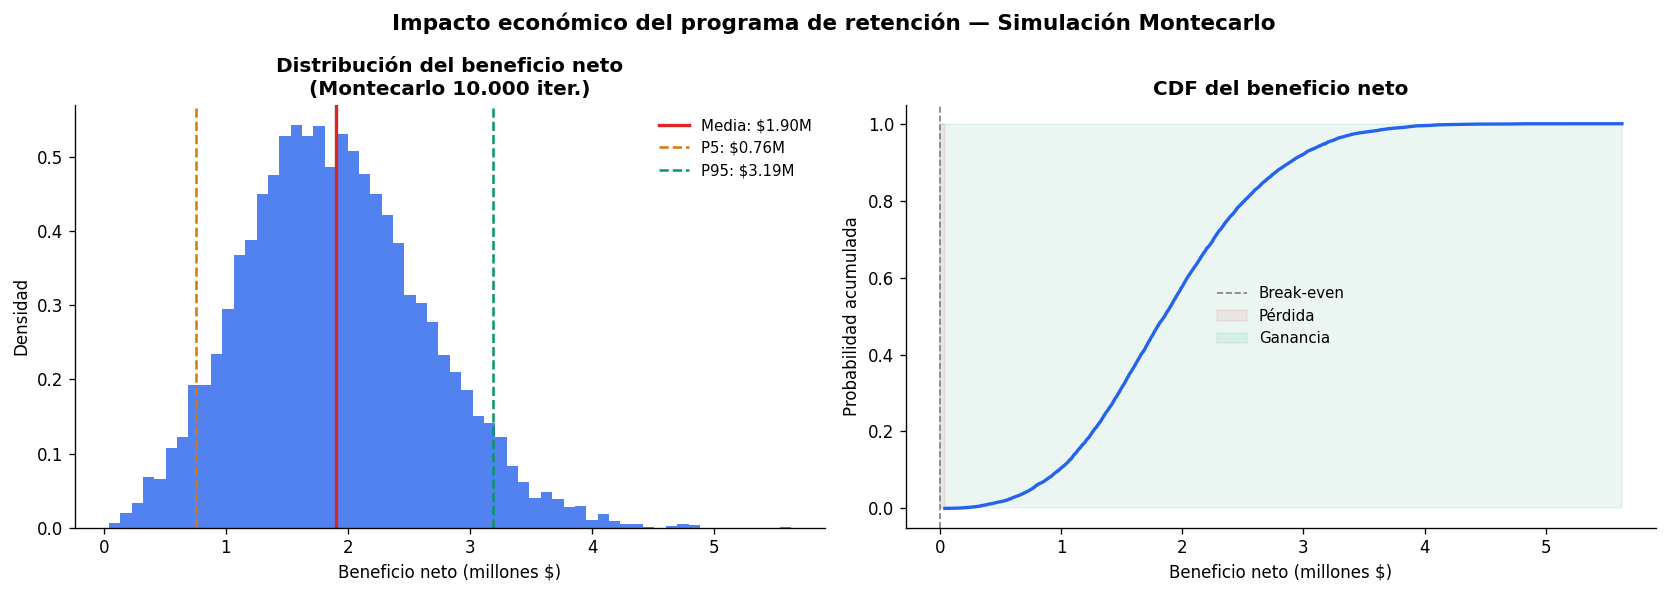

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(benefit_total / 1e6, bins=60, color='#2563EB', alpha=0.8, edgecolor='none', density=True)
axes[0].axvline(benefit_total.mean() / 1e6, color='#dc2626', linewidth=2,
                label=f'Media: ${benefit_total.mean()/1e6:.2f}M')
axes[0].axvline(np.percentile(benefit_total, 5) / 1e6, color='#d97706',
                linestyle='--', linewidth=1.5, label=f'P5: ${np.percentile(benefit_total,5)/1e6:.2f}M')
axes[0].axvline(np.percentile(benefit_total, 95) / 1e6, color='#059669',
                linestyle='--', linewidth=1.5, label=f'P95: ${np.percentile(benefit_total,95)/1e6:.2f}M')
axes[0].set_xlabel('Beneficio neto (millones $)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución del beneficio neto\n(Montecarlo 10.000 iter.)', fontweight='bold')
axes[0].legend(frameon=False, fontsize=9)

# CDF
sorted_b = np.sort(benefit_total / 1e6)
axes[1].plot(sorted_b, np.linspace(0, 1, N_SIM), color='#2563EB', linewidth=2)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=1, label='Break-even')
axes[1].fill_betweenx([0, 1], sorted_b.min(), 0, alpha=0.08, color='#dc2626', label='Pérdida')
axes[1].fill_betweenx([0, 1], 0, sorted_b.max(), alpha=0.08, color='#059669', label='Ganancia')
axes[1].set_xlabel('Beneficio neto (millones $)')
axes[1].set_ylabel('Probabilidad acumulada')
axes[1].set_title('CDF del beneficio neto', fontweight='bold')
axes[1].legend(frameon=False, fontsize=9)

plt.suptitle('Impacto económico del programa de retención — Simulación Montecarlo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_15_montecarlo.png', bbox_inches='tight')
plt.show()


## 10. Segmentación de clientes por riesgo

In [27]:
# ── Scoring final sobre el conjunto de test ──────────────────────────────────
risk_df = X_test.copy().reset_index(drop=True)
risk_df['churn_prob'] = y_proba_b
risk_df['churn_real'] = y_test.values
risk_df['segmento']   = pd.cut(
    risk_df['churn_prob'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['Bajo (<25%)', 'Medio (25-50%)', 'Alto (50-75%)', 'Crítico (>75%)']
)

resumen = risk_df.groupby('segmento', observed=True).agg(
    clientes     = ('churn_prob', 'count'),
    churn_real   = ('churn_real', 'mean'),
    prob_media   = ('churn_prob', 'mean')
).round(3)

print("── Segmentación de riesgo ────────────────────────────────────────")
print(resumen.to_string())


── Segmentación de riesgo ────────────────────────────────────────
                clientes  churn_real  prob_media
segmento                                        
Bajo (<25%)         1698       0.018       0.014
Medio (25-50%)        35       0.457       0.354
Alto (50-75%)         42       0.786       0.631
Crítico (>75%)       251       0.980       0.947


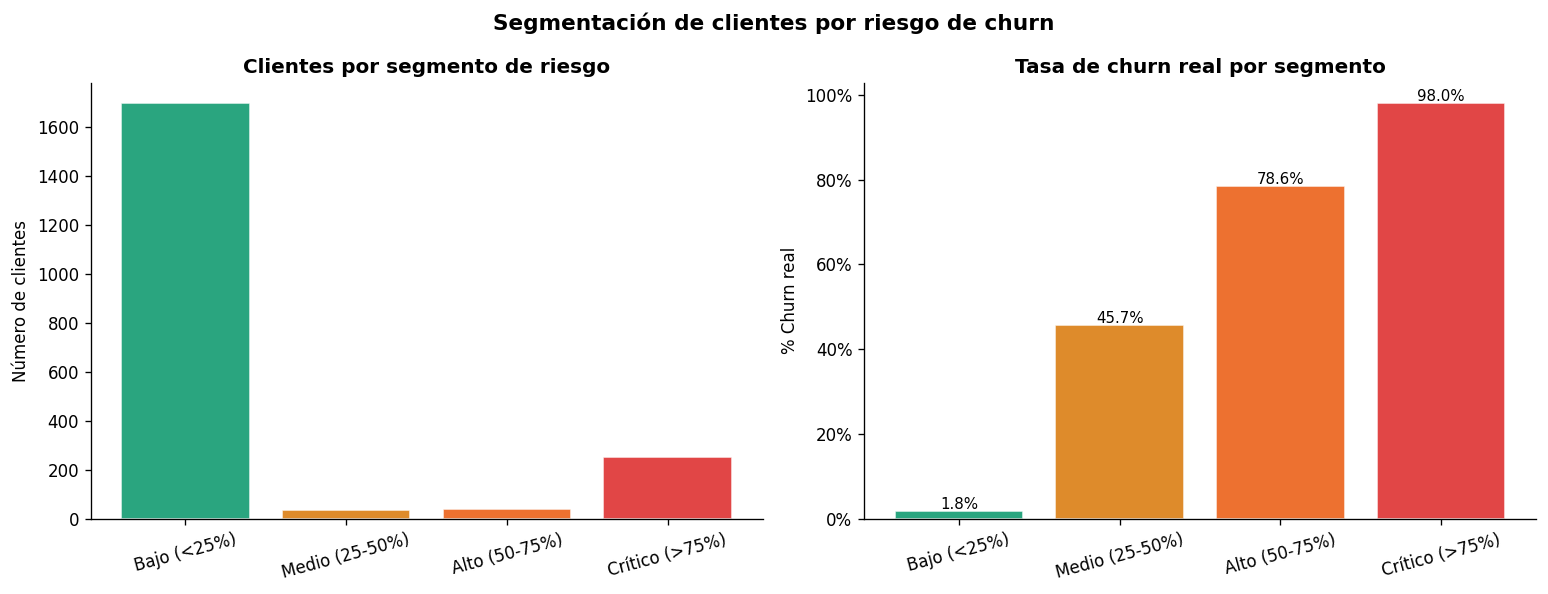


Top 10 clientes con mayor probabilidad de churn:
 clientnum  churn_prob       segmento  customer_age  months_inactive_12_mon  total_trans_ct  contacts_count_12_mon
 712660308    0.999313 Crítico (>75%)            44                       3              40                      3
 718653333    0.999109 Crítico (>75%)            45                       3              31                      3
 809849358    0.999025 Crítico (>75%)            55                       6              36                      3
 714581358    0.998708 Crítico (>75%)            48                       3              36                      4
 713027058    0.998702 Crítico (>75%)            46                       2              31                      3
 709560258    0.998634 Crítico (>75%)            49                       3              38                      4
 771422883    0.998398 Crítico (>75%)            57                       4              35                      2
 711232608    0.998272 Crítico

In [28]:
colors_seg = ['#059669', '#d97706', '#EA580C', '#dc2626']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts_seg = risk_df['segmento'].value_counts().sort_index()
axes[0].bar(counts_seg.index.astype(str), counts_seg.values,
            color=colors_seg, alpha=0.85, edgecolor='white')
axes[0].set_title('Clientes por segmento de riesgo', fontweight='bold')
axes[0].set_ylabel('Número de clientes')
axes[0].tick_params(axis='x', rotation=15)

rates_seg = risk_df.groupby('segmento', observed=True)['churn_real'].mean() * 100
axes[1].bar(rates_seg.index.astype(str), rates_seg.values,
            color=colors_seg, alpha=0.85, edgecolor='white')
axes[1].set_title('Tasa de churn real por segmento', fontweight='bold')
axes[1].set_ylabel('% Churn real')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(rates_seg.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Segmentación de clientes por riesgo de churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_16_segmentos.png', bbox_inches='tight')
plt.show()

print("\nTop 10 clientes con mayor probabilidad de churn:")
cols_show = ['clientnum','churn_prob', 'segmento', 'customer_age',
             'months_inactive_12_mon', 'total_trans_ct', 'contacts_count_12_mon']
print(risk_df.sort_values('churn_prob', ascending=False)[cols_show].head(10).to_string(index=False))


## 11. Resumen final

In [29]:
print("=" * 60)
print(f"  MODELO SELECCIONADO: {best_name}")
print("=" * 60)
for k, v in results[best_name].items():
    print(f"  {k:<12}: {v:.4f}")
print()
print("  Ranking de modelos por ROC-AUC:")
print(results_df[['ROC-AUC', 'Recall', 'F1']].round(4).to_string())
print()
print("  Segmentación final:")
for seg, row in resumen.iterrows():
    print(f"    {str(seg):<22} | {int(row['clientes']):>4} clientes | Churn real: {row['churn_real']:.1%}")
print("=" * 60)


  MODELO SELECCIONADO: XGBoost
  Accuracy    : 0.9704
  Precision   : 0.9522
  Recall      : 0.8585
  F1          : 0.9029
  ROC-AUC     : 0.9919

  Ranking de modelos por ROC-AUC:
                     ROC-AUC  Recall      F1
XGBoost               0.9919  0.8585  0.9029
AdaBoost              0.9887  0.8308  0.8838
Random Forest         0.9838  0.7600  0.8401
SVM (RBF)             0.9597  0.6800  0.7714
Neural Network        0.9576  0.7169  0.7715
Logistic Regression   0.9177  0.5538  0.6498

  Segmentación final:
    Bajo (<25%)            | 1698 clientes | Churn real: 1.8%
    Medio (25-50%)         |   35 clientes | Churn real: 45.7%
    Alto (50-75%)          |   42 clientes | Churn real: 78.6%
    Crítico (>75%)         |  251 clientes | Churn real: 98.0%
